<a href="https://colab.research.google.com/github/Lyv-ux/DI_Bootcamp/blob/main/DailyChallengew5d1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Step 1: Loading and Preprocessing Data ---
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


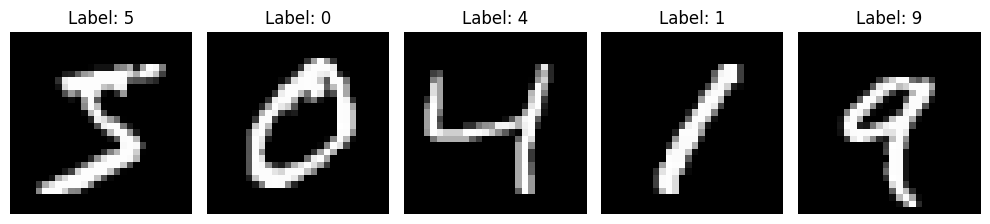


--- Step 2: Building the Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Step 3: Training the Model ---
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9160 - loss: 0.2884 - val_accuracy: 0.9633 - val_loss: 0.1293
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9638 - loss: 0.1209 - val_accuracy: 0.9738 - val_loss: 0.0888
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9753 - loss: 0.0805 - val_accuracy: 0.9770 - val_loss: 0.0810
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9809 - loss: 0.0619 - val_accuracy: 0.9807 - val_loss: 0.0710
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9850 - loss: 0.0473 - val_accuracy: 0.9802 - val_loss: 0.0668
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9885 - loss: 0.0363 - val_accuracy: 0.9800 - val_loss: 0.0730
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9904 - loss: 0.0288 - val_accuracy: 0.9832 - val_loss: 0.0634
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.99

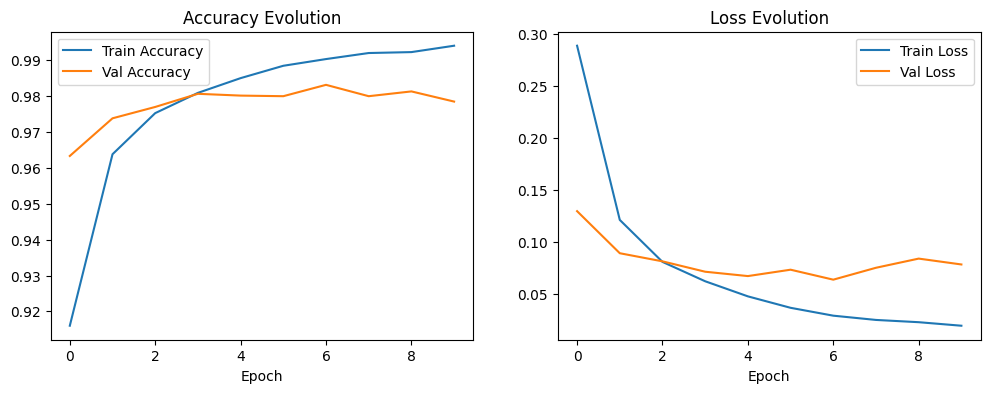


--- Step 4: Evaluating Performance ---

Final Test Accuracy: 0.9774
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


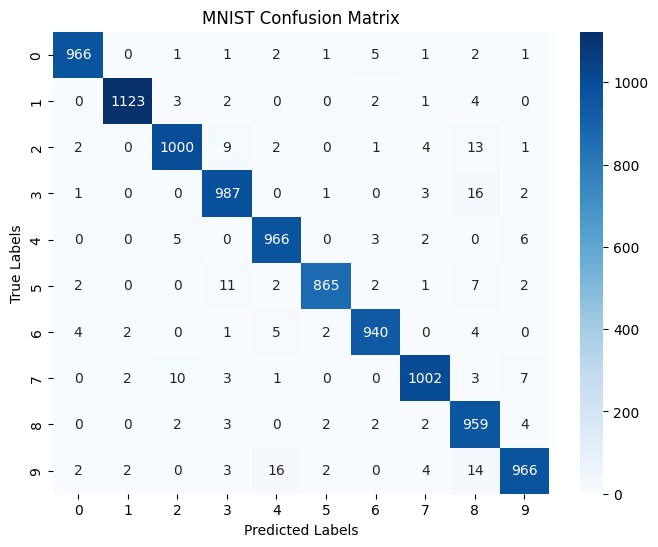


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.97      0.98      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.94      0.98      0.96       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# =====================================================================
# 1. LOAD AND PREPROCESS THE MNIST DATASET
# =====================================================================
print("--- Step 1: Loading and Preprocessing Data ---")
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Save a copy of raw test labels for evaluation later
y_test_raw = y_test.copy()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test, num_classes=10)

# Display sample images
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# =====================================================================
# 2. BUILD A FULLY CONNECTED NEURAL NETWORK
# =====================================================================
print("\n--- Step 2: Building the Model ---")
# Define a Sequential model with TWO hidden layers (as requested)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),          # Flattens 28x28 images to 784 vectors
    layers.Dense(128, activation='relu'),          # Hidden Layer 1
    layers.Dense(64, activation='relu'),           # Hidden Layer 2 (Hyperparameter tuning option)
    layers.Dense(10, activation='softmax')          # Output Layer for 10 classes
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =====================================================================
# 3. TRAIN THE NEURAL NETWORK
# =====================================================================
print("\n--- Step 3: Training the Model ---")
# Fit the model for 10 epochs
history = model.fit(
    x_train, y_train_oh,
    epochs=10,
    batch_size=64,
    validation_split=0.1  # Track performance on a validation subset
)

# Plot training history (Loss & Accuracy trends)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# =====================================================================
# 4. EVALUATE THE MODEL'S PERFORMANCE
# =====================================================================
print("\n--- Step 4: Evaluating Performance ---")
# Compute accuracy on test set
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# Get predictions
y_prob = model.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)

# Generate and display the Confusion Matrix
cm = confusion_matrix(y_test_raw, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('MNIST Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification report to see where the model struggles
print("\nClassification Report:")
print(classification_report(y_test_raw, y_pred))